# <font color="blue">**Light Cone of Scrambling (OTOC)**</font>

<img src="https://raw.githubusercontent.com/deltorobarba/science/main/nature.JPG" alt="science">


In [ ]:
!pip install cirq cirq-ionq -q
# ⚠️ Optional: Restart kernel

In [ ]:
import cirq_ionq # https://docs.ionq.com/sdks/cirq
import cirq      # https://quantumai.google/cirq/hardware/ionq/circuits

from scipy.linalg import norm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SyntaxError: invalid syntax (993372371.py, line 8)

NameError: name 'sns' is not defined

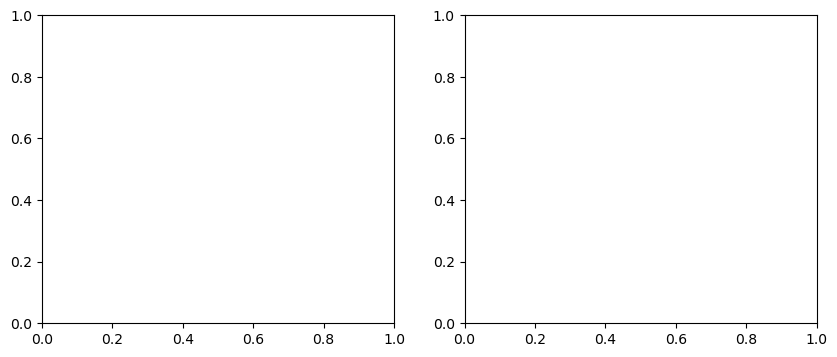

In [ ]:
# OTOC for all qubits over time. Ordered vs Chaotic
def get_unitary_from_circuit(qubits, t, h_x, h_z, steps=25):
    """
    Creates the Unitary Matrix U(t) for a specific Hamiltonian setup.
    H = Sum(Zi Zj) + h_x * Sum(Xi) + h_z * Sum(Zi)
    """
    circuit = cirq.Circuit()
    dt = t / steps
    n = len(qubits)

    for _ in range(steps):
        # 1. Interaction (ZZ) - The "Scrambler"
        for i in range(n - 1):
            circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))
            circuit.append(cirq.rz(rads=2 * dt).on(qubits[i+1]))
            circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))

        # 2. Transverse Field (X) - The "Driver"
        if h_x != 0:
            for i in range(n):
                circuit.append(cirq.rx(rads=2 * h_x * dt).on(qubits[i]))

        # 3. Longitudinal Field (Z) - The "Chaos Generator"
        # Adding this term breaks integrability and causes chaos.
        if h_z != 0:
            for i in range(n):
                circuit.append(cirq.rz(rads=2 * h_z * dt).on(qubits[i]))

    # Extract the full unitary matrix (2^N x 2^N)
    return cirq.unitary(circuit)

def calculate_otoc_heatmap(num_qubits, h_x, h_z, t_max, t_steps):
    """
    Calculates OTOC for all qubits over time to visualize the Light Cone.
    """
    qubits = cirq.LineQubit.range(num_qubits)
    times = np.linspace(0, t_max, t_steps)
    # Matrix to store results: Rows = Qubits, Cols = Time
    heatmap_data = np.zeros((num_qubits, t_steps))

    # V is always X on the first qubit (The "Butterfly")
    op_list_V = [np.eye(2)] * num_qubits
    op_list_V[0] = np.array([[0, 1], [1, 0]]) # Pauli X
    V = op_list_V[0]
    for i in range(1, num_qubits):
        V = np.kron(V, op_list_V[i])

    #print(f"Generating Heatmap (h_z={h_z})...")

    for t_idx, t in enumerate(times):
        if t == 0: continue

        # Get the global Unitary for this time point
        U = get_unitary_from_circuit(qubits, t, h_x, h_z) # Using previous function
        U_dag = U.conj().T

        # Calculate OTOC for each qubit j as the "Probe"
        for j in range(num_qubits):
            # W is Z on qubit j
            op_list_W = [np.eye(2)] * num_qubits
            op_list_W[j] = np.array([[1, 0], [0, -1]]) # Pauli Z

            # Construct W matrix
            W = op_list_W[0]
            for k in range(1, num_qubits):
                W = np.kron(W, op_list_W[k])

            # Heisenberg evolution: W(t) = U^dag * W * U
            W_t = U_dag @ W @ U

            # Commutator magnitude
            commutator = W_t @ V - V @ W_t
            heatmap_data[j, t_idx] = np.linalg.norm(commutator) ** 2

    return times, heatmap_data

# --- Execution ---
n_qubits = 6 # Kept small for simulation speed
t_max = 20.0
t_steps = 25

# Generate data for Chaotic vs Ordered
_, data_ordered = calculate_otoc_heatmap(n_qubits, 1.0, 0.0, t_max, t_steps)
times, data_chaotic = calculate_otoc_heatmap(n_qubits, 1.0, 0.5, t_max, t_steps)

# --- Plotting ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Define your desired font size
small_size = 7

# Plot 1
sns.heatmap(data_ordered, ax=ax1, cmap='magma', xticklabels=np.round(times, 1))
ax1.set_title("Ordered (h_z=0): Ballistic Spread", fontsize=small_size + 2)
ax1.set_xlabel("Time (t)", fontsize=small_size)
ax1.set_ylabel("Qubit Index", fontsize=small_size)
ax1.tick_params(axis='both', labelsize=small_size)

# Adjust Colorbar 1
cbar1 = ax1.collections[0].colorbar
cbar1.ax.tick_params(labelsize=small_size)

# Plot 2
sns.heatmap(data_chaotic, ax=ax2, cmap='magma', xticklabels=np.round(times, 1))
ax2.set_title("Chaotic (h_z=0.5): Scrambling / Diffusion", fontsize=small_size + 2)
ax2.set_xlabel("Time (t)", fontsize=small_size)
ax2.set_ylabel("Qubit Index", fontsize=small_size)
ax2.tick_params(axis='both', labelsize=small_size)

# Adjust Colorbar 2
cbar2 = ax2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=small_size)

plt.tight_layout()
plt.show()